In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from category_encoders import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../input/titanic/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.drop(columns ="Ticket", inplace=True)

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,S


In [8]:
df.shape

(891, 11)

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
round(df["Age"].median(),0)

28.0

In [11]:
df["Cabin"].mode()[0]

'B96 B98'

In [12]:
df["Cabin"] = df["Cabin"].fillna(df["Cabin"].mode()[0])
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0]) 

In [13]:
df["Age"] = df["Age"].groupby([df["Pclass"], df["Sex"]]).apply(lambda x: x.fillna(x.mean()))

In [14]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Cabin          0
Embarked       0
dtype: int64

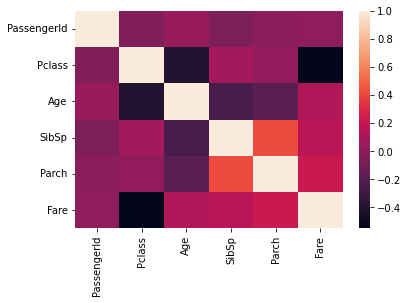

In [15]:
correlation = df.select_dtypes("number").drop(columns = "Survived").corr()
sns.heatmap(correlation);

In [16]:
df["Survived"].corr(df["Pclass"])

-0.3384810359610148

In [17]:
df["Survived"].corr(df["Fare"])

0.2573065223849625

In [18]:
df.drop(columns = "Fare", inplace = True)

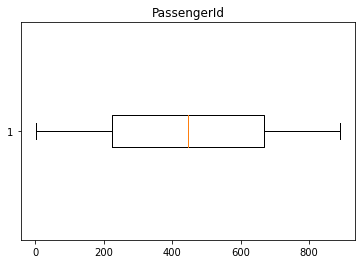

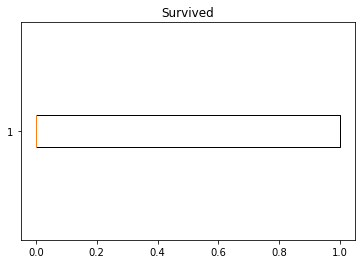

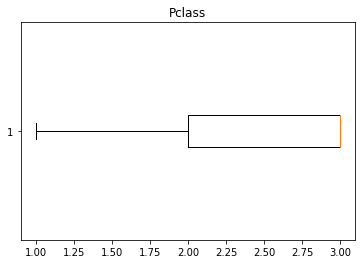

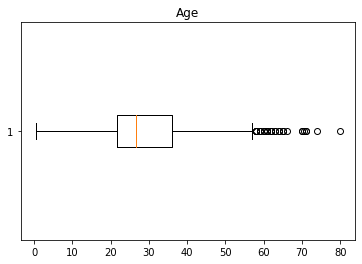

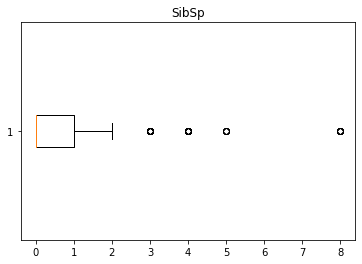

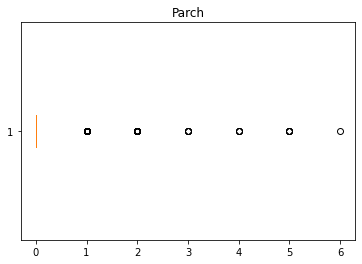

In [19]:
for i in df.select_dtypes("number").columns:
    
    plt.figure()
    plt.title(f'{i}')
    plt.boxplot(df[i], vert=False);

In [20]:
df.drop(columns = "PassengerId", inplace = True)
df.shape

(891, 9)

In [21]:
def outliers(df, ft):
    Q1 = df[ft].quantile(0.25)
    Q3 = df[ft].quantile(0.75)
    IQR = Q3-Q1
    
    low = Q1 - 1.5 * IQR
    top = Q3 + 1.5 * IQR
    
    ls = df.index[ (df[ft] < low ) |  (df[ft]  > top) ]
    return ls

In [22]:
index_list = []
for i in ["Pclass", "Age","SibSp", "Parch"]:
    index_list.extend(outliers(df, i))

In [23]:
def remove (df, ls):
    ls = sorted(set(ls))
    df = df.drop(ls)
    return df

In [24]:
df_new = remove(df, index_list)

In [25]:
df_new.shape

(650, 9)

In [26]:
df["Survived"].value_counts(normalize = True)

0    0.616162
1    0.383838
Name: Survived, dtype: float64

In [27]:
# just curiosity
survived_female = (df["Sex"] == "female") & (df["Survived"] == 1)
survived_female.value_counts()

False    658
True     233
dtype: int64

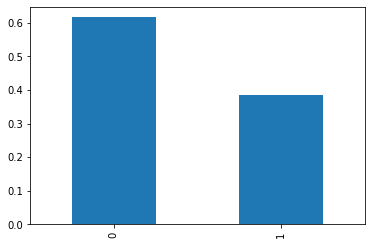

In [28]:
df["Survived"].value_counts(normalize = True).plot(kind = "bar");

In [29]:
majority_class, minority_class = round(df["Survived"].value_counts(normalize = True),2)
print(majority_class, minority_class)

0.62 0.38


In [30]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,B96 B98,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,B96 B98,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,B96 B98,S


In [31]:
# which parch has more likely to survive?

In [32]:
df["Parch"].nunique()

7

In [33]:
pivot_parch = pd.pivot_table(df, index = "Parch", values = "Survived" , aggfunc = np.mean).sort_values(by = "Survived")
pivot_parch

,Survived
Parch,
4,0.000000
6,0.000000
5,0.200000
0,0.343658
2,0.500000
1,0.550847
3,0.600000


In [34]:
#Split Data

In [35]:
target = "Survived"
X= df.drop(columns = target)
y = df[target]

In [36]:
X_train, x_test, y_train, y_test = train_test_split( X,y, test_size = 0.2, random_state = 42)

In [37]:
acc_baseline = y_train.value_counts(normalize = True).max()
print("Baseline Accuracy:", round(acc_baseline,2))

Baseline Accuracy: 0.62


In [38]:
model = make_pipeline( OneHotEncoder (use_cat_names = True), LogisticRegression(max_iter = 1000))
model.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['Name', 'Sex', 'Cabin', 'Embarked'],
                               use_cat_names=True)),
                ('logisticregression', LogisticRegression(max_iter=1000))])

In [39]:
#Evaluate

In [40]:
round(model.score(x_test, y_test), 2)

0.82

In [41]:
round(accuracy_score(y_train, model.predict(X_train)),2)

0.88

In [42]:
df.shape

(891, 9)

In [43]:
df_test = pd.read_csv("../input/titanic-test/test.csv")
df_test.shape

(418, 8)

In [44]:
y_pred = model.predict(df_test)
y_pred[:5]

array([0, 1, 0, 0, 1])

In [45]:
pred = pd.DataFrame(y_pred)
sub_df = pd.read_csv("../input/titanic/gender_submission.csv")
datasets = pd.concat([sub_df["PassengerId"], pred], axis = 1)
datasets.columns = ["PassengerId", "Survived"]
datasets.to_csv("./titanic_survival_result", index = False)